# Практическое задание — анализ метода ближайшего центроида для WSD

В этом проекте исследуется адекватность простого метода определения значения слова: значение выбирается по косинусной мере между векторным представлением слова и центроидами классов. Цель работы — найти случаи, в которых этот метод даёт ошибку, и проанализировать, с чем она связана.

Основные этапы работы:
1. Получение векторных представлений слов из корпуса **SemCor** с помощью модели **deberta-v3-base**.
2. Вычисление центроидов для основных значений леммы.
3. Классификация тестовых примеров по косинусному сходству к центроидам.
4. Визуализация примеров с помощью **PCA** и **t-SNE**.
5. Анализ ошибок на реальных леммах `table` и `yard`.
6. Дополнительная геометрическая иллюстрация поведения косинусного сходства на искусственном двумерном примере.

In [90]:
!pip install adjustText


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn.functional as F
import transformers
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk

from collections import Counter, defaultdict
from transformers import AutoTokenizer, AutoModel
from nltk.corpus import semcor
from nltk.corpus.reader.wordnet import Lemma
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Torch version:", torch.__version__)
print("Transformers version:", transformers.__version__)

Torch version: 2.10.0+cpu
Transformers version: 5.3.0


In [2]:
from transformers import AutoTokenizer, AutoModel
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

model = AutoModel.from_pretrained(model_name, output_hidden_states=True).to(DEVICE)

model.eval()

BEST_LAYER = 8

print("Model loaded successfully")
print("Device:", DEVICE)
print("Best layer:", BEST_LAYER)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully
Device: cpu
Best layer: 8


In [3]:
nltk.download("semcor")
nltk.download("wordnet")

[nltk_data] Downloading package semcor to
[nltk_data]     C:\Users\zador\AppData\Roaming\nltk_data...
[nltk_data]   Package semcor is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\zador\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
import os

os.makedirs("figures", exist_ok=True)
print("Folder 'figures' is ready")

Folder 'figures' is ready


In [5]:
sentences = semcor.sents()
tagged_sents = semcor.tagged_sents(tag='sem')

print("Number of plain sentences:", len(sentences))
print("Number of tagged sentences:", len(tagged_sents))
print("First sentence:")
print(sentences[0])

Number of plain sentences: 37176
Number of tagged sentences: 37176
First sentence:
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', 'Atlanta', "'s", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']


In [6]:
sentence_words = ["Watson", "stumbled", "down", "the", "bank", "."]
bank_word_index = 4

encoding = tokenizer(
    sentence_words,
    is_split_into_words=True,
    return_tensors="pt",
    truncation=True
)

word_ids = encoding.word_ids(batch_index=0)

model_inputs = {k: v.to(DEVICE) for k, v in encoding.items()}

with torch.no_grad():
    outputs = model(**model_inputs)

layer_embeddings = outputs.hidden_states[BEST_LAYER][0].cpu()

token_indices = [i for i, wid in enumerate(word_ids) if wid == bank_word_index]

bank_embedding = layer_embeddings[token_indices].mean(dim=0)

print("Sentence words:", sentence_words)
print("Target word:", sentence_words[bank_word_index])
print("Word ids:", word_ids)
print("Token indices for 'bank':", token_indices)
print("Embedding shape:", bank_embedding.shape)
print(bank_embedding[:10])

Sentence words: ['Watson', 'stumbled', 'down', 'the', 'bank', '.']
Target word: bank
Word ids: [0, 1, 2, 3, 4, 5]
Token indices for 'bank': [4]
Embedding shape: torch.Size([768])
tensor([ 0.2612,  0.7905,  0.3171, -0.0025,  0.0673, -0.8066, -0.9346, -0.5459,
         1.1182, -0.4558], dtype=torch.float16)


## Этап 1: Получение векторных представлений для лемм

На этом этапе используется модель **deberta-v3-base** для получения векторных представлений слов в контексте. Далее эти представления используются для вычисления центроидов значений и последующей классификации примеров.

In [7]:
def get_word_embedding(sentence_words, target_word_index, layer_idx=BEST_LAYER):
    encoding = tokenizer(
        sentence_words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True
    )

    word_ids = encoding.word_ids(batch_index=0)
    model_inputs = {k: v.to(DEVICE) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**model_inputs)

    layer_embeddings = outputs.hidden_states[layer_idx][0].cpu()

    token_indices = [
        i for i, wid in enumerate(word_ids)
        if wid == target_word_index
    ]

    if len(token_indices) == 0:
        return None

    return layer_embeddings[token_indices].mean(dim=0)


In [8]:
emb = get_word_embedding(sentence_words, bank_word_index)

print("Embedding shape from function:", emb.shape if emb is not None else None)
print(emb[:10] if emb is not None else None)

Embedding shape from function: torch.Size([768])
tensor([ 0.2612,  0.7905,  0.3171, -0.0025,  0.0673, -0.8066, -0.9346, -0.5459,
         1.1182, -0.4558], dtype=torch.float16)


## Этап 2: Извлечение примеров для леммы

На этом шаге из корпуса **SemCor** извлекаются все примеры употребления заданной леммы вместе с их размеченными значениями. Эти примеры затем используются для построения обучающей и тестовой выборок и последующего анализа метода ближайшего центроида.

In [9]:
from nltk.corpus.reader.wordnet import Lemma

def extract_lemma_occurrences(lemma_target, max_examples=200):
    occurrences = []

    for sent in semcor.tagged_sents(tag='sem'):

        sentence_words = []
        targets_in_sent = []

        for item in sent:

            if hasattr(item, "leaves"):
                leaves = item.leaves()
                start_idx = len(sentence_words)
                sentence_words.extend(leaves)
                end_idx = len(sentence_words) - 1

                if hasattr(item, "label"):
                    label = item.label()

                    if isinstance(label, Lemma):
                        lemma_name = label.name()

                        if lemma_name == lemma_target:
                            targets_in_sent.append({
                                "word": " ".join(leaves),
                                "sense": label.synset(),
                                "target_start": start_idx,
                                "target_end": end_idx
                            })

            else:
                if isinstance(item, str):
                    sentence_words.append(item)
                else:
                    sentence_words.extend(item)

        if len(targets_in_sent) > 0:
            sentence = " ".join(sentence_words)

            for target in targets_in_sent:
                occurrences.append({
                    "word": target["word"],
                    "sense": target["sense"],
                    "sentence": sentence,
                    "sentence_words": sentence_words.copy(),
                    "target_start": target["target_start"],
                    "target_end": target["target_end"]
                })

                if len(occurrences) >= max_examples:
                    return occurrences

    return occurrences

In [10]:
examples = extract_lemma_occurrences("bank", max_examples=20)

print("Number of examples:", len(examples))
print()

for ex in examples[:5]:
    print("WORD:", ex["word"])
    print("SENSE:", ex["sense"])
    print("SENTENCE:", ex["sentence"])
    print()

Number of examples: 20

WORD: banks
SENSE: Synset('depository_financial_institution.n.01')
SENTENCE: The bill , which Daniel said he drafted personally , would force banks , insurance firms , pipeline companies and other corporations to report such property to the state treasurer .

WORD: banks
SENSE: Synset('depository_financial_institution.n.01')
SENTENCE: Dewey Lawrence , a Tyler lawyer representing the Texas Bankers Association , sounded the opposition keynote when he said it would force banks to violate their contractual obligations with depositors and undermine the confidence of bank customers .

WORD: bank
SENSE: Synset('depository_financial_institution.n.01')
SENTENCE: Dewey Lawrence , a Tyler lawyer representing the Texas Bankers Association , sounded the opposition keynote when he said it would force banks to violate their contractual obligations with depositors and undermine the confidence of bank customers .

WORD: banks
SENSE: Synset('depository_financial_institution.n.01'

In [11]:
all_bank_examples = extract_lemma_occurrences("bank", max_examples=1000)

sense_counts = Counter(ex["sense"] for ex in all_bank_examples)

print("Number of total bank examples:", len(all_bank_examples))
print()

for sense, count in sense_counts.most_common():
    print(sense, "->", count)

Number of total bank examples: 40

Synset('depository_financial_institution.n.01') -> 20
Synset('bank.n.01') -> 14
Synset('bank.n.03') -> 2
Synset('bank.v.01') -> 2
Synset('bank.n.04') -> 1
Synset('bank.v.02') -> 1


In [12]:
def get_word_embedding_from_example(example, layer_idx=BEST_LAYER):
    sentence_words = example["sentence_words"]
    target_start = example["target_start"]
    target_end = example["target_end"]

    encoding = tokenizer(
        sentence_words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True
    )

    word_ids = encoding.word_ids(batch_index=0)

    model_inputs = {k: v.to(DEVICE) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**model_inputs)

    layer_embeddings = outputs.hidden_states[layer_idx][0].cpu()

    token_indices = [
        i for i, wid in enumerate(word_ids)
        if wid is not None and target_start <= wid <= target_end
    ]

    if len(token_indices) == 0:
        return None

    word_embedding = layer_embeddings[token_indices].mean(dim=0)
    return word_embedding

In [13]:
top_senses = [sense for sense, count in sense_counts.most_common(2)]

filtered_examples = [
    ex for ex in all_bank_examples
    if ex["sense"] in top_senses
]

test_ex = filtered_examples[0]

print("WORD:", test_ex["word"])
print("SENSE:", test_ex["sense"])
print("SENTENCE:", test_ex["sentence"])

emb = get_word_embedding_from_example(test_ex)

print()
print("Embedding shape:", emb.shape if emb is not None else None)

WORD: banks
SENSE: Synset('depository_financial_institution.n.01')
SENTENCE: The bill , which Daniel said he drafted personally , would force banks , insurance firms , pipeline companies and other corporations to report such property to the state treasurer .

Embedding shape: torch.Size([768])


In [14]:
def cosine_similarity(a, b):
    return F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

In [15]:
def compute_centroid(embeddings):
    if len(embeddings) == 0:
        raise ValueError("compute_centroid: empty embeddings list")

    return torch.stack(embeddings).mean(dim=0)

## Этап 3: Анализ леммы

После извлечения примеров для леммы для двух основных значений вычисляются центроиды векторных представлений. Далее тестовые примеры классифицируются по косинусному сходству к этим центроидам.

Этот этап включает:
1. выбор двух наиболее частотных значений леммы;
2. разделение примеров на обучающие и тестовые;
3. вычисление центроидов по обучающим примерам;
4. классификацию тестовых примеров методом ближайшего центроида;
5. анализ ошибок классификации.

In [16]:
def analyze_lemma(lemma, max_examples=1000, min_examples_per_sense=4, keep_top_k_for_analysis=2):
    all_examples = extract_lemma_occurrences(lemma, max_examples=max_examples)

    if len(all_examples) == 0:
        return None

    sense_counts = Counter(ex["sense"] for ex in all_examples)

    if len(sense_counts) < 2:
        return None

    all_senses = list(sense_counts.keys())

    top_senses = [sense for sense, count in sense_counts.most_common(keep_top_k_for_analysis)]

    filtered_examples = [
        ex for ex in all_examples
        if ex["sense"] in top_senses
    ]

    sense_to_examples = defaultdict(list)
    for ex in filtered_examples:
        sense_to_examples[ex["sense"]].append(ex)

    if any(len(v) < min_examples_per_sense for v in sense_to_examples.values()):
        return None

    train_examples = []
    test_examples = []

    for sense, exs in sense_to_examples.items():
        split_idx = int(0.7 * len(exs))

        if split_idx == 0 or split_idx == len(exs):
            return None

        train_examples.extend(exs[:split_idx])
        test_examples.extend(exs[split_idx:])

    train_sense_to_embeddings = defaultdict(list)
    test_sense_to_embeddings = defaultdict(list)

    for ex in train_examples:
        emb = get_word_embedding_from_example(ex)
        if emb is not None:
            train_sense_to_embeddings[ex["sense"]].append(emb)

    for ex in test_examples:
        emb = get_word_embedding_from_example(ex)
        if emb is not None:
            test_sense_to_embeddings[ex["sense"]].append(emb)

    if len(train_sense_to_embeddings) < 2 or len(test_sense_to_embeddings) < 2:
        return None

    train_sense_to_centroid = {}
    for sense, emb_list in train_sense_to_embeddings.items():
        if len(emb_list) == 0:
            return None
        train_sense_to_centroid[sense] = compute_centroid(emb_list)

    def predict_sense_from_embedding(embedding, centroids):
        best_sense = None
        best_score = -1

        for sense, centroid in centroids.items():
            score = cosine_similarity(embedding, centroid)
            if score > best_score:
                best_score = score
                best_sense = sense

        return best_sense, best_score

    test_results = []
    for sense, emb_list in test_sense_to_embeddings.items():
        for emb in emb_list:
            pred_sense, score = predict_sense_from_embedding(emb, train_sense_to_centroid)
            test_results.append({
                "true_sense": sense,
                "pred_sense": pred_sense,
                "score": score,
                "correct": (sense == pred_sense),
                "embedding": emb
            })

    errors = [r for r in test_results if not r["correct"]]

    return {
        "lemma": lemma,
        "all_examples": all_examples,                  
        "sense_counts": sense_counts,                  
        "all_senses": all_senses,                    
        "top_senses": top_senses,                     
        "filtered_examples": filtered_examples,        
        "train_examples": train_examples,
        "test_examples": test_examples,
        "train_sense_to_embeddings": train_sense_to_embeddings,
        "test_sense_to_embeddings": test_sense_to_embeddings,
        "train_sense_to_centroid": train_sense_to_centroid,
        "test_results": test_results,
        "errors": errors
    }

## Этап 4: Визуализация результатов

После классификации примеров используются методы **PCA** и **t-SNE** для снижения размерности и визуализации результатов в двумерном пространстве. На графиках отображаются обучающие точки, тестовые точки и центры классов.

Ошибочно классифицированные тестовые точки выделяются отдельно, чтобы можно было анализировать структуру ошибок и их расположение относительно основных групп примеров.

In [84]:
def visualize_result(res, method="pca", perplexity=5, save_path=None):
    def l2_normalize(v):
        norm = np.linalg.norm(v)
        if norm == 0:
            return v
        return v / norm

    train_sense_to_embeddings = res["train_sense_to_embeddings"]
    test_results = res["test_results"]
    train_sense_to_centroid = res["train_sense_to_centroid"]

    # train embeddings
    all_train_embeddings = []
    all_train_labels = []
    for sense, emb_list in train_sense_to_embeddings.items():
        for emb in emb_list:
            emb_np = emb.numpy()
            emb_np = l2_normalize(emb_np)
            all_train_embeddings.append(emb_np)
            all_train_labels.append(str(sense))

    all_train_embeddings = np.array(all_train_embeddings)

    # test embeddings
    all_test_embeddings = []
    all_test_labels = []
    for r in test_results:
        emb_np = r["embedding"].numpy()
        emb_np = l2_normalize(emb_np)
        all_test_embeddings.append(emb_np)
        all_test_labels.append(str(r["true_sense"]))

    all_test_embeddings = np.array(all_test_embeddings)

    # centroids
    centroid_senses = list(train_sense_to_centroid.keys())
    all_centroids = []
    for sense in centroid_senses:
        centroid_np = train_sense_to_centroid[sense].numpy()
        centroid_np = l2_normalize(centroid_np)
        all_centroids.append(centroid_np)

    all_centroids = np.array(all_centroids)
    centroid_labels = [str(sense) for sense in centroid_senses]

    X_all = np.vstack([all_train_embeddings, all_test_embeddings, all_centroids])

    n_train = len(all_train_embeddings)
    n_test = len(all_test_embeddings)
    n_cent = len(all_centroids)

    if method == "pca":
        reducer = PCA(n_components=2)
        X_2d = reducer.fit_transform(X_all)

    elif method == "tsne":
        reducer = TSNE(
            n_components=2,
            random_state=42,
            perplexity=perplexity,
            metric="cosine",
            init="pca"
        )
        X_2d = reducer.fit_transform(X_all)

    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    train_2d = X_2d[:n_train]
    test_2d = X_2d[n_train:n_train + n_test]
    cent_2d = X_2d[n_train + n_test:n_train + n_test + n_cent]

    unique_labels = sorted(set(all_train_labels))
    colors = ["blue", "green", "red", "orange", "purple", "brown"]
    label_to_color = {label: colors[i % len(colors)] for i, label in enumerate(unique_labels)}

    plt.figure(figsize=(10, 7))

    # train points
    for label in unique_labels:
        idxs = [i for i, l in enumerate(all_train_labels) if l == label]
        plt.scatter(
            train_2d[idxs, 0],
            train_2d[idxs, 1],
            c=label_to_color[label],
            label=f"train: {label}",
            alpha=0.7
        )

    # test points
    for i, label in enumerate(all_test_labels):
        marker = "x" if not test_results[i]["correct"] else "o"
        plt.scatter(
            test_2d[i, 0],
            test_2d[i, 1],
            c=label_to_color[label],
            marker=marker,
            s=100,
            edgecolors="black" if marker == "o" else None
        )

    # centroids
    for i, label in enumerate(centroid_labels):
        plt.scatter(
            cent_2d[i, 0],
            cent_2d[i, 1],
            c=label_to_color[label],
            marker="X",
            s=300,
            edgecolors="black"
        )

    plt.title(f"{method.upper()} visualization of lemma '{res['lemma']}'")
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

In [18]:
candidate_lemmas = ["bank", "plant", "yard", "table", "arm", "paper", "board", "land", "head", "line"]

results_summary = []

for lemma in candidate_lemmas:
    res = analyze_lemma(lemma, max_examples=1000)
    if res is not None:
        results_summary.append((lemma, len(res["errors"]), res["sense_counts"]))
        print(f"{lemma}: errors = {len(res['errors'])}")
        print(res["sense_counts"])
        print()

bank: errors = 1
Counter({Synset('depository_financial_institution.n.01'): 20, Synset('bank.n.01'): 14, Synset('bank.n.03'): 2, Synset('bank.v.01'): 2, Synset('bank.n.04'): 1, Synset('bank.v.02'): 1})

plant: errors = 9
Counter({Synset('plant.n.01'): 63, Synset('plant.n.02'): 36, Synset('plant.v.01'): 8, Synset('implant.v.01'): 2, Synset('establish.v.02'): 1})

yard: errors = 5
Counter({Synset('yard.n.01'): 34, Synset('yard.n.02'): 12, Synset('yard.n.03'): 1})

table: errors = 4
Counter({Synset('table.n.01'): 52, Synset('table.n.02'): 25, Synset('table.n.03'): 4})

arm: errors = 1
Counter({Synset('arm.n.01'): 68, Synset('arm.v.01'): 4, Synset('arm.n.02'): 1, Synset('arm.n.04'): 1, Synset('weapon.n.01'): 1, Synset('arm.v.02'): 1})

paper: errors = 3
Counter({Synset('paper.n.01'): 29, Synset('composition.n.08'): 21, Synset('newspaper.n.01'): 12, Synset('paper.n.04'): 4, Synset('paper.n.05'): 3, Synset('newspaper.n.02'): 2})

board: errors = 2
Counter({Synset('board.n.01'): 28, Synset('bo

In [45]:
yard_res = analyze_lemma("yard", max_examples=1000)
table_res = analyze_lemma("table", max_examples=1000)

print("yard errors:", len(yard_res["errors"]) if yard_res is not None else None)
print("table errors:", len(table_res["errors"]) if table_res is not None else None)

yard errors: 5
table errors: 4


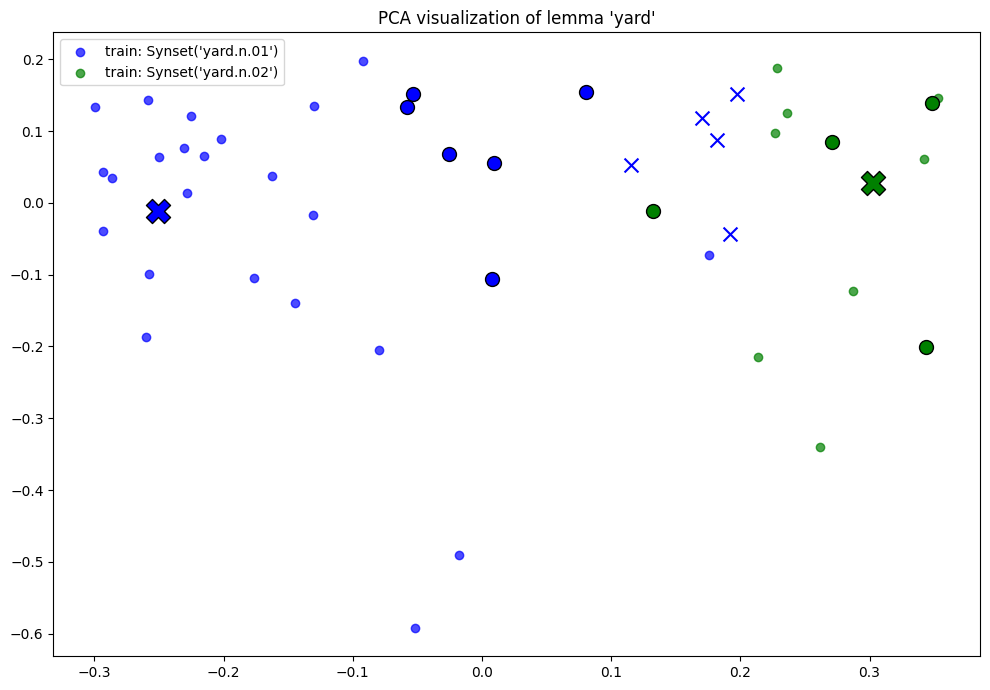

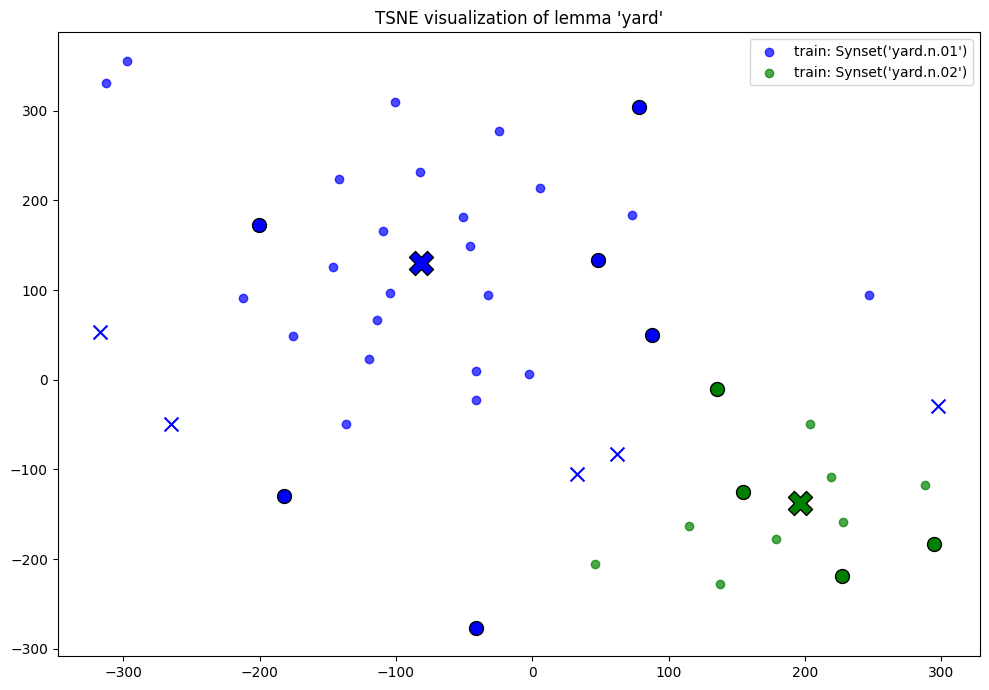

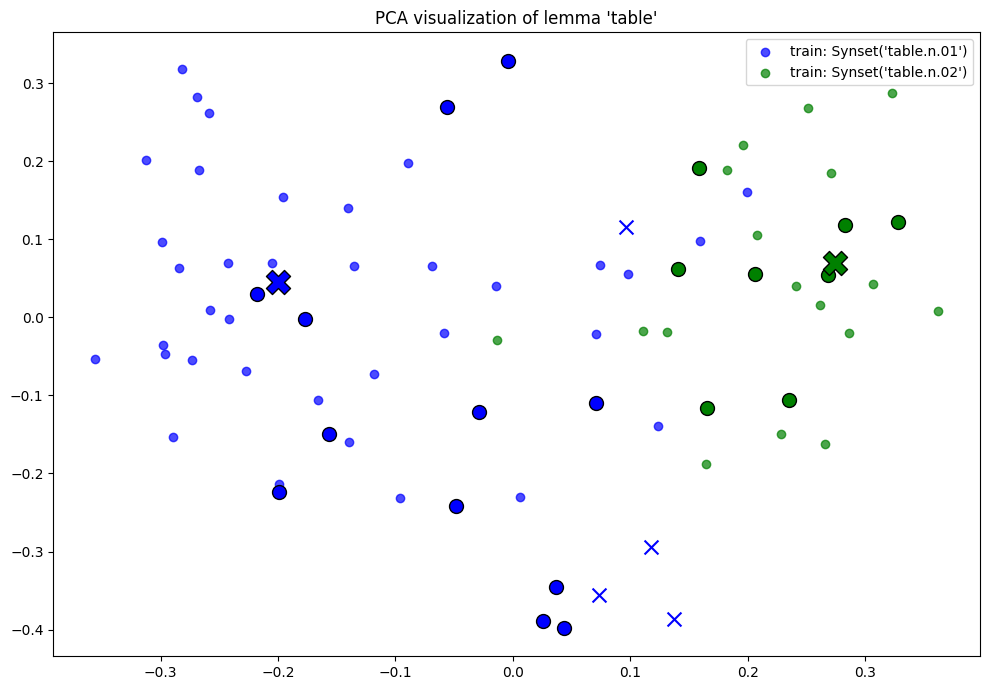

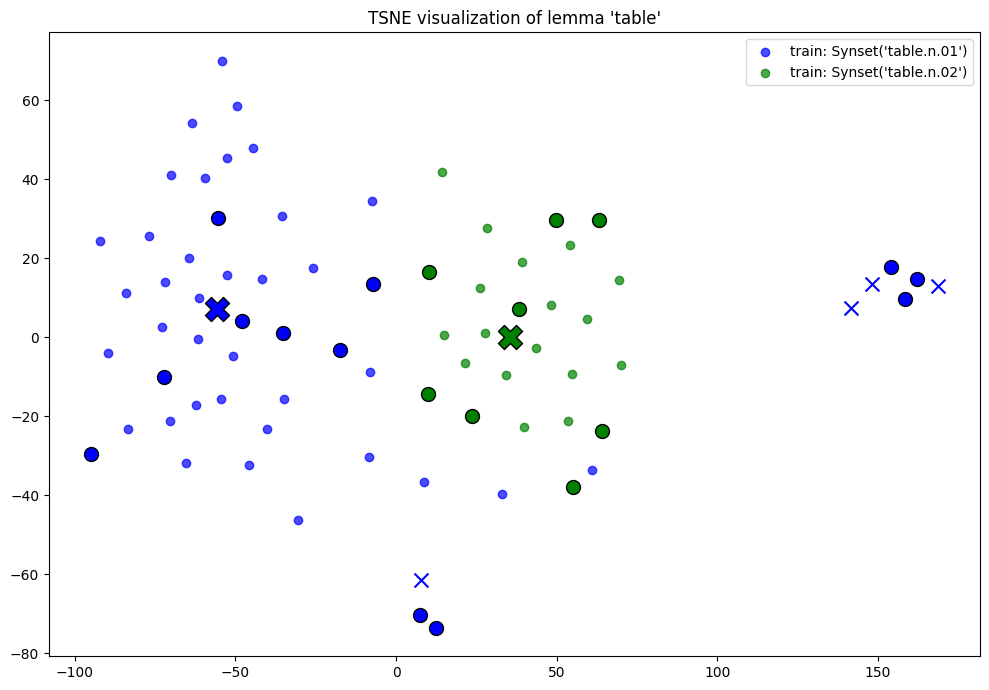

In [87]:
visualize_result(yard_res, method="pca", save_path="figures/yard_pca.png")
visualize_result(yard_res, method="tsne", save_path="figures/yard_tsne.png")

visualize_result(table_res, method="pca", save_path="figures/table_pca.png")
visualize_result(table_res, method="tsne", save_path="figures/table_tsne.png")

In [47]:
print("Ошибки для yard:")
for i, err in enumerate(yard_res["errors"]):
    print(f"\nОшибка {i}")
    print("TRUE:", err["true_sense"])
    print("PRED:", err["pred_sense"])
    print("SCORE:", err["score"])

Ошибки для yard:

Ошибка 0
TRUE: Synset('yard.n.01')
PRED: Synset('yard.n.02')
SCORE: 0.71240234375

Ошибка 1
TRUE: Synset('yard.n.01')
PRED: Synset('yard.n.02')
SCORE: 0.6875

Ошибка 2
TRUE: Synset('yard.n.01')
PRED: Synset('yard.n.02')
SCORE: 0.67333984375

Ошибка 3
TRUE: Synset('yard.n.01')
PRED: Synset('yard.n.02')
SCORE: 0.685546875

Ошибка 4
TRUE: Synset('yard.n.01')
PRED: Synset('yard.n.02')
SCORE: 0.7431640625


In [22]:
print("Ошибки для table:")
for i, err in enumerate(table_res["errors"]):
    print(f"\nОшибка {i}")
    print("TRUE:", err["true_sense"])
    print("PRED:", err["pred_sense"])
    print("SCORE:", err["score"])

Ошибки для table:

Ошибка 0
TRUE: Synset('table.n.01')
PRED: Synset('table.n.02')
SCORE: 0.64697265625

Ошибка 1
TRUE: Synset('table.n.01')
PRED: Synset('table.n.02')
SCORE: 0.76904296875

Ошибка 2
TRUE: Synset('table.n.01')
PRED: Synset('table.n.02')
SCORE: 0.65771484375

Ошибка 3
TRUE: Synset('table.n.01')
PRED: Synset('table.n.02')
SCORE: 0.693359375


## Этап 5: Визуализация результатов с ID ошибок

На этом шаге используется расширенная версия визуализации, в которой ошибочно классифицированные тестовые точки помечаются номерами ошибок. Это позволяет напрямую сопоставлять точки на графиках с конкретными примерами предложений и с последующим анализом ближайших обучающих контекстов.

Для каждой леммы строятся графики **PCA** и **t-SNE**, что позволяет сравнить как глобальную, так и локальную структуру ошибок.

In [91]:
from adjustText import adjust_text

def visualize_result_with_error_ids(res, method="pca", perplexity=5, save_path=None):
    def l2_normalize(v):
        norm = np.linalg.norm(v)
        if norm == 0:
            return v
        return v / norm

    train_sense_to_embeddings = res["train_sense_to_embeddings"]
    test_results = res["test_results"]
    train_sense_to_centroid = res["train_sense_to_centroid"]

    # train embeddings
    all_train_embeddings = []
    all_train_labels = []
    for sense, emb_list in train_sense_to_embeddings.items():
        for emb in emb_list:
            emb_np = l2_normalize(emb.numpy())
            all_train_embeddings.append(emb_np)
            all_train_labels.append(str(sense))

    all_train_embeddings = np.array(all_train_embeddings)

    # test embeddings
    all_test_embeddings = []
    all_test_labels = []
    for r in test_results:
        emb_np = l2_normalize(r["embedding"].numpy())
        all_test_embeddings.append(emb_np)
        all_test_labels.append(str(r["true_sense"]))

    all_test_embeddings = np.array(all_test_embeddings)

    # centroids
    centroid_senses = list(train_sense_to_centroid.keys())
    all_centroids = []
    for sense in centroid_senses:
        centroid_np = l2_normalize(train_sense_to_centroid[sense].numpy())
        all_centroids.append(centroid_np)

    all_centroids = np.array(all_centroids)
    centroid_labels = [str(sense) for sense in centroid_senses]

    X_all = np.vstack([all_train_embeddings, all_test_embeddings, all_centroids])

    n_train = len(all_train_embeddings)
    n_test = len(all_test_embeddings)
    n_cent = len(all_centroids)

    if method == "pca":
        reducer = PCA(n_components=2)
        X_2d = reducer.fit_transform(X_all)

    elif method == "tsne":
        reducer = TSNE(
            n_components=2,
            random_state=42,
            perplexity=perplexity,
            metric="cosine",
            init="pca"
        )
        X_2d = reducer.fit_transform(X_all)

    train_2d = X_2d[:n_train]
    test_2d = X_2d[n_train:n_train+n_test]
    cent_2d = X_2d[n_train+n_test:]

    unique_labels = sorted(set(all_train_labels))
    colors = ["blue","green","red","orange","purple","brown"]
    label_to_color = {label: colors[i % len(colors)] for i,label in enumerate(unique_labels)}

    plt.figure(figsize=(10,7))

    # train
    for label in unique_labels:
        idxs = [i for i,l in enumerate(all_train_labels) if l==label]
        plt.scatter(
            train_2d[idxs,0],
            train_2d[idxs,1],
            c=label_to_color[label],
            label=f"train: {label}",
            alpha=0.7
        )

    # test
    texts = []
    error_count = 0

    for i,label in enumerate(all_test_labels):

        marker = "x" if not test_results[i]["correct"] else "o"

        plt.scatter(
            test_2d[i,0],
            test_2d[i,1],
            c=label_to_color[label],
            marker=marker,
            s=100,
            edgecolors="black" if marker=="o" else None
        )

        if not test_results[i]["correct"]:
            txt = plt.text(
                test_2d[i,0],
                test_2d[i,1],
                f"Ошибка {error_count}",
                fontsize=10
            )
            texts.append(txt)
            error_count += 1

    # центроиды
    for i,label in enumerate(centroid_labels):
        plt.scatter(
            cent_2d[i,0],
            cent_2d[i,1],
            c=label_to_color[label],
            marker="X",
            s=300,
            edgecolors="black"
        )

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
    )

    plt.title(f"{method.upper()} visualization of lemma '{res['lemma']}' with error ids")
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

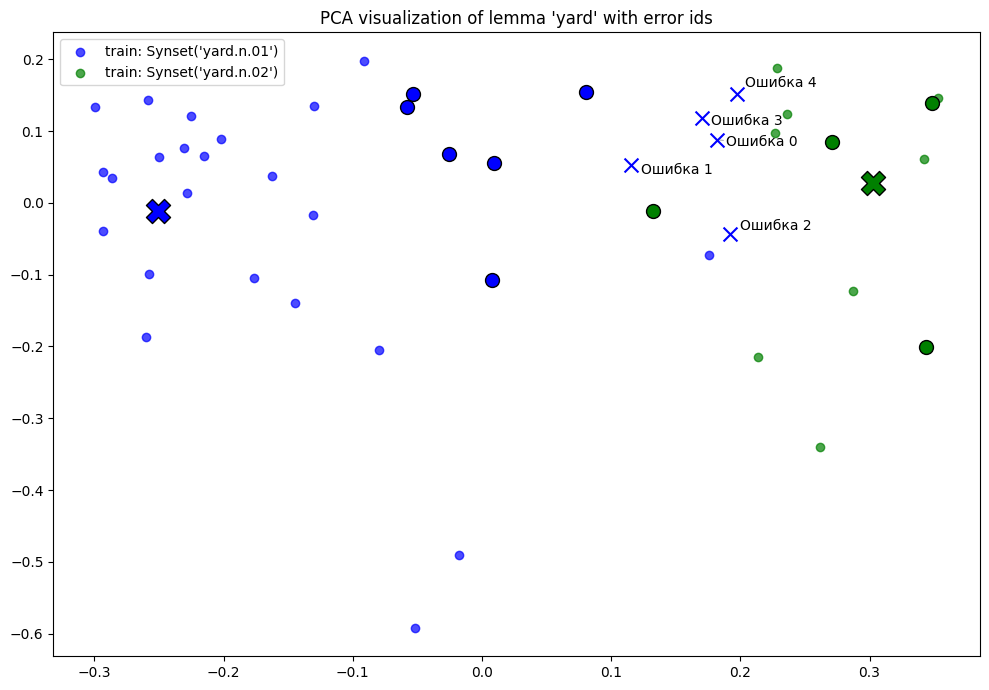

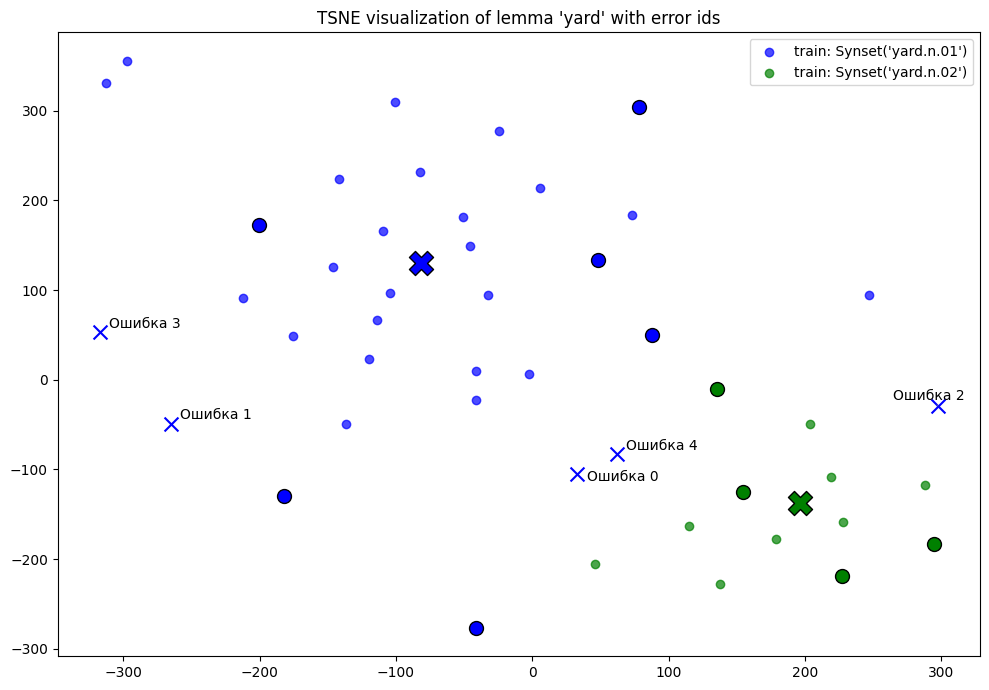

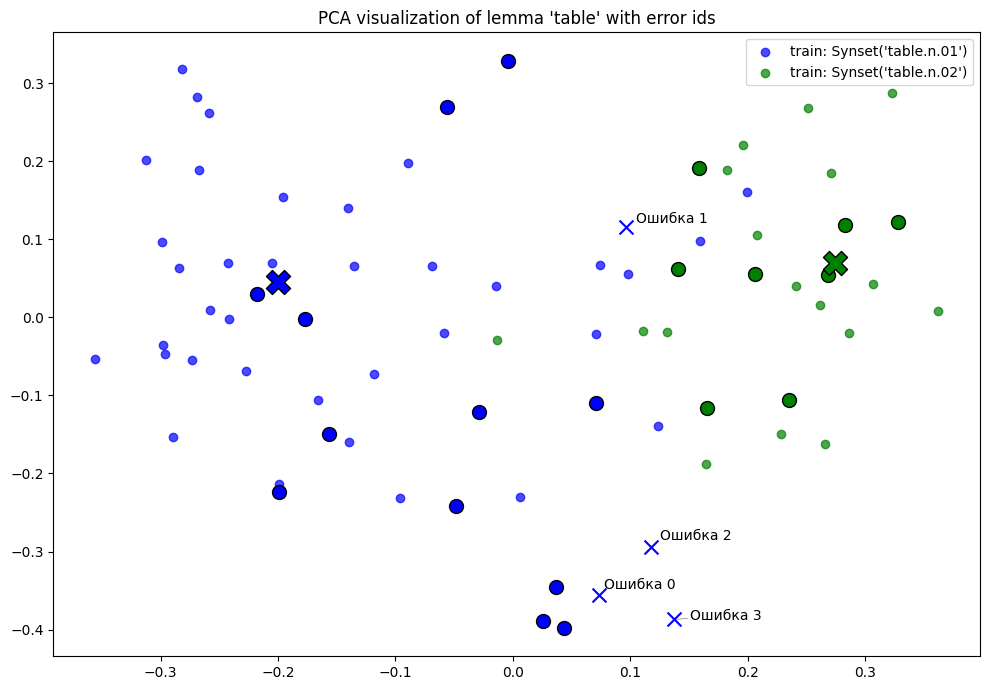

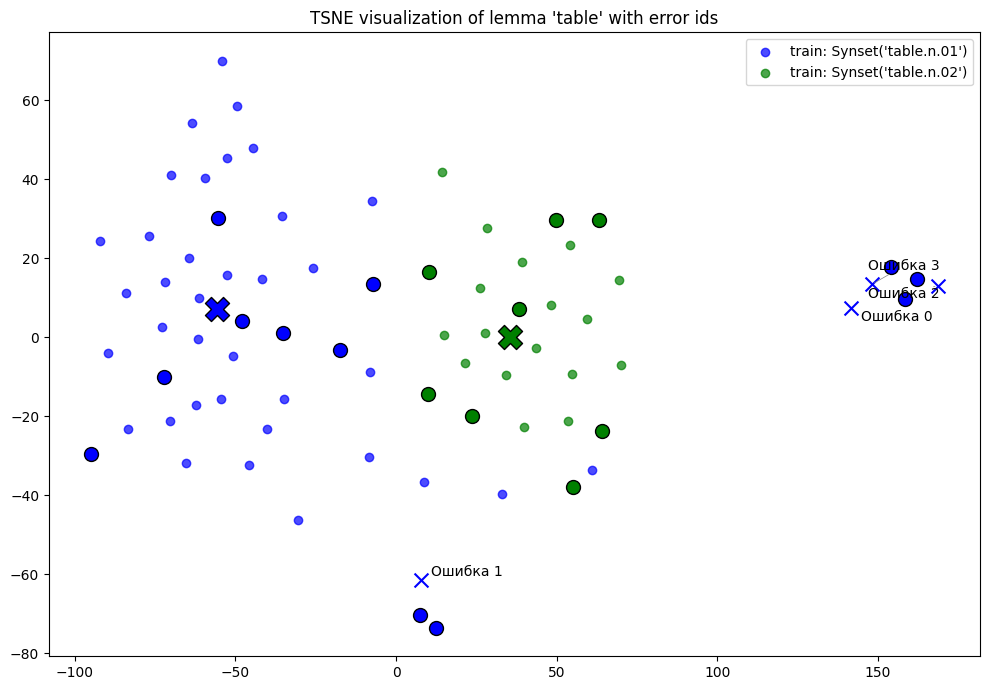

In [92]:
visualize_result_with_error_ids(yard_res, method="pca", save_path="figures/yard_pca_errors.png")
visualize_result_with_error_ids(yard_res, method="tsne", save_path="figures/yard_tsne_errors.png")

visualize_result_with_error_ids(table_res, method="pca", save_path="figures/table_pca_errors.png")
visualize_result_with_error_ids(table_res, method="tsne", save_path="figures/table_tsne_errors.png")

## Анализ ошибок и ограничения метода ближайшего центроида
В качестве основных реальных примеров были рассмотрены леммы `table` и `yard`, поскольку для них удалось найти содержательно неоднородные, но интерпретируемые группы ошибочных контекстов.

Для леммы `table` все найденные ошибки относятся к одному и тому же истинному значению `table.n.01`, связанному с таблицами в тексте, словарях, налоговых формах и структурированном представлении данных. При этом на графиках видно, что три ошибки (`0`, `2`, `3`) образуют локальную подгруппу, а ошибка `1` расположена отдельно. Дополнительный анализ ближайших обучающих примеров показывает, что и для ошибки 0, и для ошибки 1 среди соседей преобладают контексты значения `table.n.01`: *Table 1*, *Tables 1 and 2*, *figures and tables*, *Table 5-1*, *organizational charts and tables*. Однако среди ближайших примеров встречаются и контексты `table.n.02`, например *at the table's empty chairs* и *on the table by Scotty's bed*. Это означает, что ошибка возникает не случайно и не из-за полного смешения классов, а потому, что внутри `table.n.01` существуют локальные подструктуры контекстов, которые недостаточно хорошо описываются одним общим центром всего класса.

Для леммы `yard` все найденные ошибки относятся к значению `yard.n.01`, то есть к употреблению слова как меры длины. Однако содержательный анализ показывает, что внутри этого значения встречаются разные типы контекстов. Среди самих ошибок есть повествовательные примеры расстояния: *About 300 yards up the creek...*, *He had not covered a hundred yards...*, *While several yards from it...*, *A few yards beyond...*. Кроме того, ошибка 1 представляет другой тип употребления: *bought yards of an inexpensive material...*, где `yards` обозначает меру количества ткани. Среди ближайших обучающих соседей ошибки 0, напротив, преобладают спортивно-статистические контексты: *280 yards rushing*, *271 yards on 55 carries*, *22 yards short*, *30 yards ... five yards ... 56-yard touchdown run*. Следовательно, внутри одного и того же значения `yard.n.01` в данных присутствуют разные контекстные реализации, и один общий центроид оказывается слишком грубым представителем для всей этой структуры.

Таким образом, анализ реальных лемм показывает, что метод ближайшего центроида может систематически ошибаться на подструктурах внутри одного значения. При этом эти подструктуры не обязаны образовывать один компактный кластер на всех визуализациях. В случае `table` локальная группировка ошибок выражена заметнее, а в случае `yard` особенно важно не столько геометрическое положение точек, сколько содержательная неоднородность контекстов внутри одного значения. Следовательно, реальные примеры `table` и `yard` полезны прежде всего как указание на ограниченность метода ближайшего центроида.


## Сравнение PCA и t-SNE

Для лемм `table` и `yard` были использованы два метода снижения размерности: **PCA** и **t-SNE**. Оба метода позволяют перенести эмбеддинги в двумерное пространство и визуально сравнить расположение точек, однако их результаты нельзя считать полностью эквивалентными.

**PCA** — это линейный метод снижения размерности. Он лучше сохраняет глобальную геометрию данных, поэтому именно визуализация PCA является более надёжной для интерпретации общего расположения кластеров и их центров. В рассматриваемых примерах PCA показывает, что для `table` ошибки частично образуют локальную группу, а для `yard` они распределены более неоднородно.

**t-SNE** — нелинейный метод, ориентированный в первую очередь на сохранение локальных соседств между точками. Поэтому на его графиках локальные группы часто выглядят более компактными и заметными. В случае `table` t-SNE также выделяет компактную группу из трёх ошибок, но для `yard` структура ошибок выглядит менее устойчивой и более рассеянной. Поэтому t-SNE не следует использовать для строгой интерпретации расстояний до центров кластеров и общей геометрии классов.

Следовательно, **PCA и t-SNE не дают полностью одинаковые результаты**. Для `table` оба метода качественно согласуются в том, что часть ошибок образует локальную подгруппу. Для `yard` такой согласованности уже меньше: визуализации скорее указывают на сложную и неоднородную структуру ошибок, чем на один компактный ошибочный кластер. При этом содержательный анализ ближайших обучающих примеров подтверждает, что в обоих случаях ошибки связаны не со случайным шумом, а с внутренней неоднородностью самих значений.

## Анализ конкретных ошибок и ближайших обучающих примеров

Ниже приведены тексты ошибочно классифицированных предложений, а также ближайшие обучающие примеры для отдельных ошибок. Это позволяет проверить, относятся ли ошибочные точки к содержательно однородным контекстам и действительно ли среди их соседей преобладают примеры того же истинного значения.

In [25]:
def print_error_sentences(res):
    print(f"Лемма: {res['lemma']}")
    print("=" * 100)

    error_id = 0
    for ex, result in zip(res["test_examples"], res["test_results"]):
        if not result["correct"]:
            print(f"Ошибка {error_id}")
            print("WORD:", ex["word"])
            print("TRUE:", result["true_sense"])
            print("PRED:", result["pred_sense"])
            print("SCORE:", result["score"])
            print("SENTENCE:", ex["sentence"])
            print("-" * 100)
            error_id += 1

In [95]:
print_error_sentences(table_res)
print_error_sentences(yard_res)

Лемма: table
Ошибка 0
WORD: table
TRUE: Synset('table.n.01')
PRED: Synset('table.n.02')
SCORE: 0.64697265625
SENTENCE: The results of the study , based on collision integrals computed from the latest critically evaluated data on intermolecular forces in air , will be reported in the form of a table of viscosity , thermal conductivity , thermal diffusion , and diffusion coefficients at temperatures of 1000 to 10000 * * f and of logarithm of pressure in atmospheres from * * f to * * f times normal density .
----------------------------------------------------------------------------------------------------
Ошибка 1
WORD: Table
TRUE: Synset('table.n.01')
PRED: Synset('table.n.02')
SCORE: 0.76904296875
SENTENCE: If you elect to use the Standard Deduction or the Tax Table , and later find you should have itemized your deductions , you may do so by filing an amended return within the time prescribed for filing a claim for refund .
-------------------------------------------------------------

In [27]:
def show_nearest_train_examples(res, error_number=0, top_k=8):

    errors = [r for r in res["test_results"] if not r["correct"]]

    if error_number >= len(errors):
        print("Нет такой ошибки")
        return

    target_error = errors[error_number]
    target_emb = target_error["embedding"]

    train_examples_by_sense = defaultdict(list)
    for ex in res["train_examples"]:
        train_examples_by_sense[ex["sense"]].append(ex)

    scored_examples = []

    for sense, emb_list in res["train_sense_to_embeddings"].items():
        ex_list = train_examples_by_sense[sense]

        for ex, emb in zip(ex_list, emb_list):
            score = cosine_similarity(target_emb, emb)
            scored_examples.append({
                "score": score,
                "sense": sense,
                "word": ex["word"],
                "sentence": ex["sentence"]
            })

    scored_examples = sorted(scored_examples, key=lambda x: x["score"], reverse=True)

    print(f"Лемма: {res['lemma']}")
    print(f"Ошибка {error_number}")
    print("TRUE:", target_error["true_sense"])
    print("PRED:", target_error["pred_sense"])
    print("=" * 100)

    for i, item in enumerate(scored_examples[:top_k]):
        print(f"Сосед {i+1}")
        print("SENSE:", item["sense"])
        print("SIMILARITY:", item["score"])
        print("WORD:", item["word"])
        print("SENTENCE:", item["sentence"])
        print("-" * 100)

In [101]:
show_nearest_train_examples(table_res, error_number=0, top_k=8)
show_nearest_train_examples(yard_res, error_number=0, top_k=8)
show_nearest_train_examples(yard_res, error_number=1, top_k=8)
show_nearest_train_examples(table_res, error_number=1, top_k=8)

Лемма: table
Ошибка 0
TRUE: Synset('table.n.01')
PRED: Synset('table.n.02')
Сосед 1
SENSE: Synset('table.n.01')
SIMILARITY: 0.609375
WORD: Table
SENTENCE: The registration figures given in Table 2 must be interpreted with caution since the estimate for eligible electors were made without the benefit of a reliable census .
----------------------------------------------------------------------------------------------------
Сосед 2
SENSE: Synset('table.n.01')
SIMILARITY: 0.59765625
WORD: Table
SENTENCE: The **f values are listed in Table 1 together with the measured surface temperatures and arc voltages .
----------------------------------------------------------------------------------------------------
Сосед 3
SENSE: Synset('table.n.02')
SIMILARITY: 0.59375
WORD: table
SENTENCE: His stethoscope was on the table by Scotty 's bed and he picked it up and wagged it at Scotty .
----------------------------------------------------------------------------------------------------
Сосед 4
SENSE:

## Интерпретация ошибок для `table`

Для леммы `table` все ошибки относятся к истинному значению `table.n.01`. По самим ошибочным предложениям видно, что речь идёт о контекстах, связанных с таблицами, словарными формами, налоговыми таблицами и структурированным представлением данных. Среди ближайших обучающих примеров для ошибки 1 также явно преобладают контексты `table.n.01`: *Table 1*, *Tables 1 and 2*, *figures and tables*, *Table 5-1*, *organizational charts and tables*, *in Table 1*. Однако среди ближайших соседей встречаются и контексты значения `table.n.02`, например *at the table's empty chairs* и *on the table by Scotty's bed*.

Следовательно, ошибка возникает в смешанном локальном окружении: точка содержательно всё ещё принадлежит `table.n.01`, но рядом уже появляются контексты другого значения. Это хорошо согласуется с гипотезой о том, что внутри `table.n.01` существуют локальные подструктуры, и один общий центроид недостаточно точно описывает всё значение целиком.

## Интерпретация ошибок для `yard`

Для леммы `yard` все ошибки относятся к истинному значению `yard.n.01`, то есть к употреблению слова как меры длины. Однако внутри этого значения в данных встречаются разные типы контекстов.

Среди самих ошибок есть повествовательные пространственные контексты:
- *About 300 yards up the creek...*
- *He had not covered a hundred yards...*
- *While several yards from it...*
- *A few yards beyond...*

Кроме того, ошибка 1 показывает другой тип употребления:
- *bought yards of an inexpensive material...*

Здесь `yards` обозначает не пространственное расстояние в сцене, а меру количества ткани.

Если посмотреть на ближайшие обучающие примеры для ошибки 0, то среди них преобладают ещё и спортивно-статистические контексты:
- *280 yards rushing*
- *271 yards on 55 carries*
- *22 yards short*
- *30 yards ... five yards ... 56-yard touchdown run*

Таким образом, внутри одного и того же значения `yard.n.01` в корпусе присутствуют разные контекстные реализации: повествовательное расстояние, мера количества ткани и спортивно-статистические употребления. Это объясняет, почему один общий центроид может оказаться недостаточно точным представителем всего значения.

## Замечание об ошибке 1 для `yard`

Ошибка 1 отличается от остальных ошибок для `yard`. В предложении *bought yards of an inexpensive material...* слово `yards` относится к тому же значению `yard.n.01`, но реализуется в другом типе контекста — как мера количества ткани, а не как пространственное расстояние в повествовании. Поэтому эта ошибка содержательно выделяется даже внутри набора ошибок одного и того же значения и показывает, насколько неоднородными могут быть контексты внутри одного словарного смысла.

## Искусственный пример с нормированными векторами

Ниже приведён дополнительный искусственный пример, в котором все векторы нормированы до единичной длины. Такой пример позволяет отдельно проиллюстрировать геометрию косинусного сходства и связь между косинусной мерой и евклидовым расстоянием на единичной окружности.

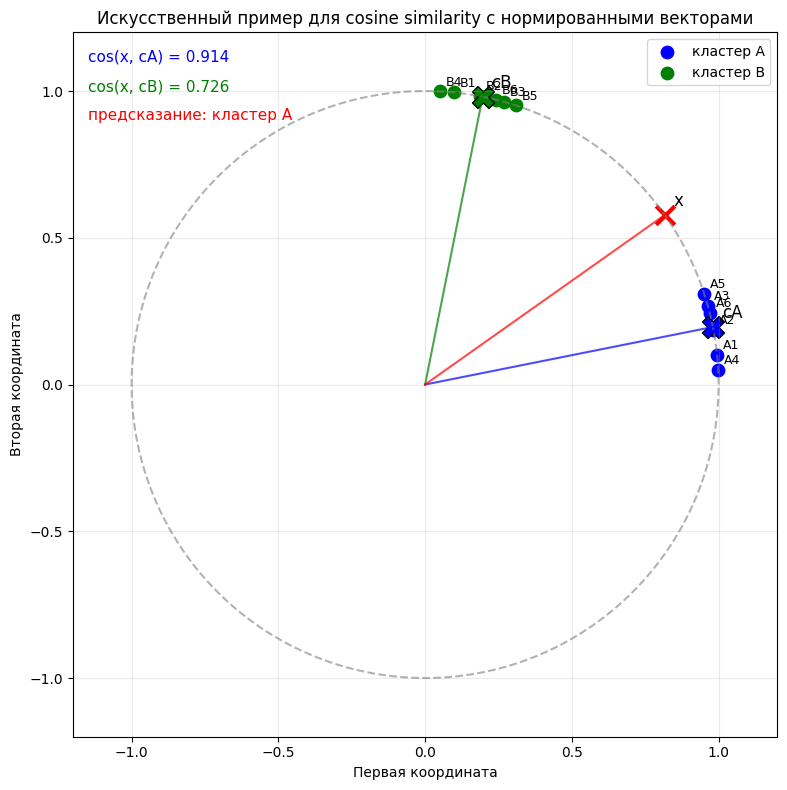

Все точки нормированы: ||v|| = 1
cos(x, cA) = 0.913812
cos(x, cB) = 0.726363
Алгоритм относит x к кластеру A


In [94]:
def normalize(v):
    v = np.array(v, dtype=float)
    norm = np.linalg.norm(v)
    if norm == 0:
        return v
    return v / norm

def cosine(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

cA = normalize([1.0, 0.2])
cB = normalize([0.2, 1.0])

# Кластер A
A = np.array([
    normalize([1.00, 0.10]),
    normalize([0.95, 0.18]),
    normalize([0.90, 0.25]),
    normalize([0.98, 0.05]),
    normalize([0.92, 0.30]),
    normalize([0.88, 0.22]),
])

# Кластер B
B = np.array([
    normalize([0.10, 1.00]),
    normalize([0.18, 0.95]),
    normalize([0.25, 0.90]),
    normalize([0.05, 0.98]),
    normalize([0.30, 0.92]),
    normalize([0.22, 0.88]),
])

# Тестовая точка
x = normalize([0.82, 0.58])

cos_A = cosine(x, cA)
cos_B = cosine(x, cB)

pred = "A" if cos_A > cos_B else "B"

fig, ax = plt.subplots(figsize=(8, 8))

theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), linestyle="--", color="gray", alpha=0.6)

# Точки кластеров
ax.scatter(A[:, 0], A[:, 1], color="blue", s=80, label="кластер A")
ax.scatter(B[:, 0], B[:, 1], color="green", s=80, label="кластер B")

# Центры
ax.scatter(cA[0], cA[1], color="blue", marker="X", s=250, edgecolors="black")
ax.scatter(cB[0], cB[1], color="green", marker="X", s=250, edgecolors="black")

# Тестовая точка
ax.scatter(x[0], x[1], color="red", marker="x", s=180, linewidths=3)

ax.plot([0, cA[0]], [0, cA[1]], color="blue", alpha=0.7)
ax.plot([0, cB[0]], [0, cB[1]], color="green", alpha=0.7)
ax.plot([0, x[0]], [0, x[1]], color="red", alpha=0.7)

ax.text(cA[0] + 0.03, cA[1] + 0.03, "cA", fontsize=12)
ax.text(cB[0] + 0.03, cB[1] + 0.03, "cB", fontsize=12)
ax.text(x[0] + 0.03, x[1] + 0.03, "x", fontsize=12)

for i, p in enumerate(A, start=1):
    ax.text(p[0] + 0.02, p[1] + 0.02, f"A{i}", fontsize=9)

for i, p in enumerate(B, start=1):
    ax.text(p[0] + 0.02, p[1] + 0.02, f"B{i}", fontsize=9)
ax.text(-1.15, 1.10, f"cos(x, cA) = {cos_A:.3f}", color="blue", fontsize=11)
ax.text(-1.15, 1.00, f"cos(x, cB) = {cos_B:.3f}", color="green", fontsize=11)
ax.text(-1.15, 0.90, f"предсказание: кластер {pred}", color="red", fontsize=11)

ax.set_title("Искусственный пример для cosine similarity с нормированными векторами")
ax.set_xlabel("Первая координата")
ax.set_ylabel("Вторая координата")
ax.set_aspect("equal")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Все точки нормированы: ||v|| = 1")
print(f"cos(x, cA) = {cos_A:.6f}")
print(f"cos(x, cB) = {cos_B:.6f}")
print(f"Алгоритм относит x к кластеру {pred}")

## Итоговые выводы по практическому заданию

В работе был реализован метод определения значения слова по косинусной близости между эмбеддингом слова в контексте и центроидами значений. Для получения эмбеддингов использовалась модель **deberta-v3-base**, а в качестве размеченного корпуса — **SemCor**. Для двух наиболее частотных значений каждой леммы были построены обучающая и тестовая выборки, вычислены центроиды и выполнена классификация тестовых примеров методом ближайшего центроида.

Для визуального анализа использовались методы **PCA** и **t-SNE**. Сравнение показало, что они дают разные, но взаимодополняющие представления структуры данных: PCA лучше сохраняет глобальную геометрию и расположение центров, а t-SNE сильнее подчёркивает локальные соседства и компактные подгруппы точек. Поэтому PCA более надёжен для интерпретации общего расположения кластеров, а t-SNE полезен как дополнительная иллюстрация локальной структуры.

В качестве основных реальных примеров были рассмотрены леммы `table` и `yard`. Для `table` все найденные ошибки относятся к истинному значению `table.n.01`, а для `yard` — к истинному значению `yard.n.01`. Дополнительный анализ ближайших обучающих примеров показал, что у ошибочных точек действительно преобладают соседи того же истинного значения, хотя среди ближайших примеров встречаются и контексты другого значения. Это подтверждает, что ошибки связаны не со случайным шумом, а с внутренней неоднородностью соответствующих значений.

Особенно показателен пример `yard`: внутри одного и того же значения `yard.n.01` в данных встречаются разные типы контекстов — повествовательное расстояние, мера количества ткани и спортивно-статистические употребления. Для `table` также видно, что даже ошибка 1, расположенная отдельно от остальных, по ближайшим соседям остаётся содержательно связанной прежде всего с `table.n.01`, хотя её локальное окружение уже включает и примеры `table.n.02`. Это показывает, что один общий центроид может быть недостаточно точным представителем даже для одного словарного значения.

Таким образом, на реальных данных удалось найти как минимум две леммы, для которых ошибки обусловлены ограниченностью самого метода ближайшего центроида: один общий центр значения оказывается недостаточно хорошим представителем для всех его контекстов. Визуальный анализ этих примеров в сочетании с разбором предложений и ближайших обучающих контекстов показывает, что внутри одного значения могут существовать устойчивые локальные подструктуры, которые описываются одним центроидом недостаточно точно.

В целом практическое задание показывает, что метод ближайшего центроида с косинусной мерой действительно может давать систематические ошибки даже в случаях, когда внутри одного значения существуют осмысленные и повторяющиеся группы контекстов. Следовательно, этот метод полезен как базовый ориентир, но его адекватность ограничена, если структура значения оказывается неоднородной и плохо описывается одним центром.